# Part 3 — Proposed analysis method, **with a real effect**

In Part 1 we developed the proposed (circular) workflow on data with **no** real effect, and
in Part 2 we built valid alternatives (train/test split and multiple-comparison correction).
Now we repeat the simulation, but this time behavioral performance really *does* modulate the
activity of the **performance-correlated cells** (we simulate that **10% of the cells** are
genuinely modulated by behavioral performance). For those cells we add, on top of the noise, a
signal that is a scaled, mean-zero function of each trial group's performance $P$:

$$P_\text{scaled} = \frac{k\, \sigma_A}{\operatorname{std}(P)}\,(P - \overline{P})$$

The constant `k` sets how big the behavioral effect is relative to noise:
`k=1` → the signal is comparable to the noise; `k=0.1` → performance only weakly affects it.
Here `k=0.2` gives a modest correlation. All other cells remain pure noise. Then the rest of
the analysis workflow is applied exactly as in Part 1.

This notebook is self-contained: the shared building blocks from Parts 1 and 2 are imported
from `utils.py`, so it can be run on its own.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from utils import (
    simulate_null_session,
    correlate_and_select,
    annotate_corr,
    train_test_PRCA,
    fdr_bh_cells,
)

# Set a seed so the notebook is reproducible (remove for fresh random draws)
rng = np.random.default_rng(0)

Ngroups, Ncells = 20, 200
mP, sP, sA = 75, 8, 1

# Recreate the Part 1 null session (behavior, activity, cell positions).
Perf, DA, CellXY = simulate_null_session(rng, Ngroups, Ncells, mP, sP, sA)

# Part 1 circular workflow on the null data (used later as a reference panel).
r, p, SelectedCells = correlate_and_select(DA, Perf)
PRCA = DA[:, SelectedCells].mean(axis=1)

# Part 2 train/test split on the null data (the "No Real Effect" reference panel).
PRCA_test_null, Perf_test_null, _ = train_test_PRCA(DA, Perf)

q_fdr = 0.05


In [2]:
Nresponsive = round(0.1 * Ncells)
# Indices of the cells that are genuinely modulated by performance (only in the real-effect case).
CorrelatedCells = np.arange(0, Nresponsive)
UncorrelatedCells = np.arange(Nresponsive, Ncells)


In [3]:
k = 0.2  # modest correlation between cell signal and performance
Pscaled = (k * sA / np.std(Perf, ddof=1)) * (Perf - np.mean(Perf))

DA_real = sA * rng.standard_normal((Ngroups, Ncells))
DA_real[:, CorrelatedCells] += Pscaled[:, np.newaxis]

r2 = np.empty(Ncells)
p2 = np.empty(Ncells)
for j in range(Ncells):
    r2[j], p2[j] = stats.pearsonr(DA_real[:, j], Perf)
SelectedCells_real = np.where((r2 > 0.1) & (p2 < 0.05))[0]
PRCA_real = DA_real[:, SelectedCells_real].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells_real.size}")


Number of 'selected' cells: 4


## Plot the real-effect result

Now run the same standard (circular) analysis on the real-effect data and plot PRCA vs.
performance. This time there genuinely is an effect — but note the circular plot looks much
like the null one, which is exactly why we can't trust the circular method on its own.


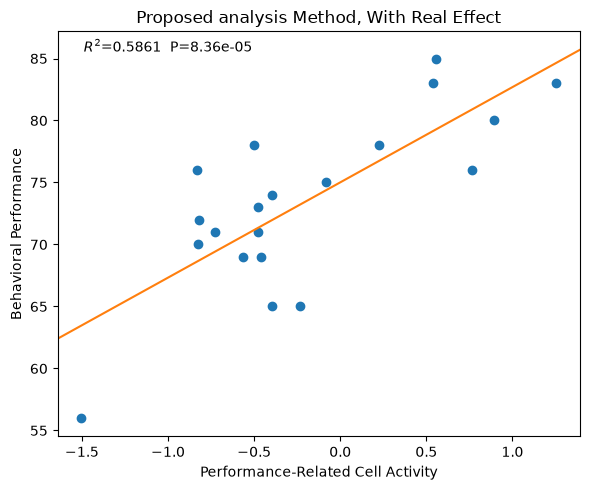

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
annotate_corr(ax, PRCA_real, Perf, "Proposed analysis Method, With Real Effect")
plt.tight_layout()
plt.show()


## Where are the "correlated" cells? (spatial view)

Because each cell has a random 2D position, we can plot the imaging field and highlight the
subset of cells that the circular workflow *selected* as correlated with performance. Here we
show the **real-effect** data: the truly performance-correlated cells (the first
`Nresponsive` cells) are outlined for reference, and the selected set should overlap them more
often than chance — though, since positions are random, the selection still looks spatially
unstructured.


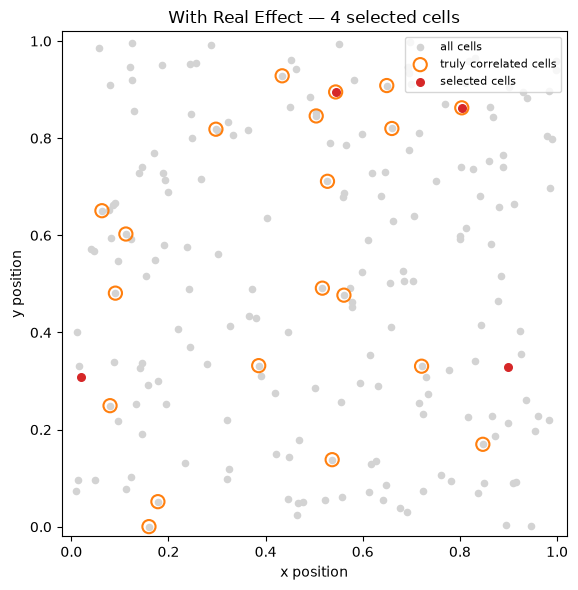

In [5]:
def plot_cells_2d(ax, selected, title, true_subset=None):
    """Plot all cells at their 2D positions, highlighting the `selected` subset."""
    ax.scatter(CellXY[:, 0], CellXY[:, 1], s=20, color="lightgray",
               label="all cells", zorder=1)
    if true_subset is not None:
        ax.scatter(CellXY[true_subset, 0], CellXY[true_subset, 1], s=90,
                   facecolors="none", edgecolors="tab:orange", linewidths=1.5,
                   label="truly correlated cells", zorder=2)
    ax.scatter(CellXY[selected, 0], CellXY[selected, 1], s=30, color="tab:red",
               label="selected cells", zorder=3)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.set_aspect("equal")
    ax.set_xlabel("x position")
    ax.set_ylabel("y position")
    ax.set_title(title)
    ax.legend(loc="upper right", fontsize=8)


fig, ax = plt.subplots(figsize=(7, 6))
plot_cells_2d(ax, SelectedCells_real,
              f"With Real Effect — {SelectedCells_real.size} selected cells",
              true_subset=CorrelatedCells)
plt.tight_layout()
plt.show()


## Do the valid methods still detect the real effect?

Now apply the independent workflows from Part 2 — the 50/50 train/test split and FDR-BH — to
the **real-effect** data. Unlike the null case, here we *want* a detection. The valid methods
have lower power than the (invalid) circular method, but they should still pick up a genuine
effect, and their result can be trusted. (LOO-CV, introduced in Extension 3, is a more
data-efficient alternative to the train/test split.)


In [6]:
# 50/50 train/test split on the real-effect data
split_real = train_test_PRCA(DA_real, Perf)

# FDR-BH on the real-effect data
fdr_real = fdr_bh_cells(DA_real, Perf, q=q_fdr)
true_hits = np.intersect1d(fdr_real, CorrelatedCells).size

print("Real-effect data (k = %.2f):" % k)
if split_real is None:
    print("  Train/test    : no cells selected on the training half")
else:
    r_tt_real, p_tt_real = stats.pearsonr(split_real[0], split_real[1])
    print(f"  Train/test    : r = {r_tt_real:+.3f}, p = {p_tt_real:.3f} "
          f"({split_real[2].size} cells selected on training half)")
print(f"  FDR-BH        : {fdr_real.size} cells discovered, "
      f"{true_hits}/{CorrelatedCells.size} are truly correlated")


Real-effect data (k = 0.20):
  Train/test    : r = -0.657, p = 0.039 (6 cells selected on training half)
  FDR-BH        : 0 cells discovered, 0/20 are truly correlated


### Stronger effects
The train/test split prevents us from detecting the false positive in the no-real-effect dataset, but with the weak effect we may also fail to see a true positive result. What if we try increasing the strength of the real effect?


In [7]:
# simulate a stronger effect, k ~ 0.6
k_strong = 0.6  # stronger correlation between cell signal and performance
Pscaled_strong = (k_strong * sA / np.std(Perf, ddof=1)) * (Perf - np.mean(Perf))

DA_real_strong = sA * rng.standard_normal((Ngroups, Ncells))
DA_real_strong[:, CorrelatedCells] += Pscaled_strong[:, np.newaxis]

r2 = np.empty(Ncells)
p2 = np.empty(Ncells)
for j in range(Ncells):
    r2[j], p2[j] = stats.pearsonr(DA_real_strong[:, j], Perf)
SelectedCells_real_strong = np.where((r2 > 0.1) & (p2 < 0.05))[0]
PRCA_real_strong = DA_real_strong[:, SelectedCells_real_strong].mean(axis=1)
print(f"Number of 'selected' cells: {SelectedCells_real_strong.size}")


Number of 'selected' cells: 18


In [8]:
# Train/test split on the stronger-effect data
split_real_strong = train_test_PRCA(DA_real_strong, Perf)

print("Weak real-effect data (train/test split):")
r_w, p_w = stats.pearsonr(split_real[0], split_real[1])
print(f"  cells selected on training half : {split_real[2].size}")
print(f"  test-half correlation           : r = {r_w:+.3f}, p = {p_w:.3f}")

print("\nStrong real-effect data (train/test split):")
r_s, p_s = stats.pearsonr(split_real_strong[0], split_real_strong[1])
print(f"  cells selected on training half : {split_real_strong[2].size}")
print(f"  test-half correlation           : r = {r_s:+.3f}, p = {p_s:.3f}")


Weak real-effect data (train/test split):
  cells selected on training half : 6
  test-half correlation           : r = -0.657, p = 0.039

Strong real-effect data (train/test split):
  cells selected on training half : 12
  test-half correlation           : r = +0.812, p = 0.004


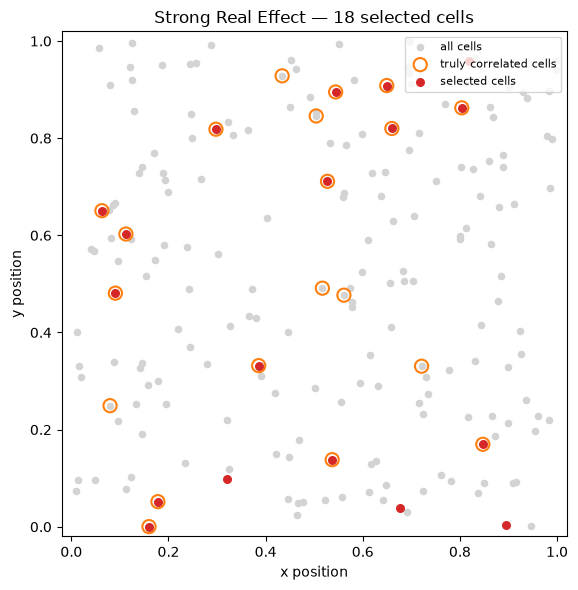

In [9]:
# reuse plot_cells_2d to plot the selected cells vs real cells

fig, ax = plt.subplots(figsize=(7, 6))
plot_cells_2d(ax, SelectedCells_real_strong,
              f"Strong Real Effect — {SelectedCells_real_strong.size} selected cells",
              true_subset=CorrelatedCells)
plt.tight_layout()
plt.show()


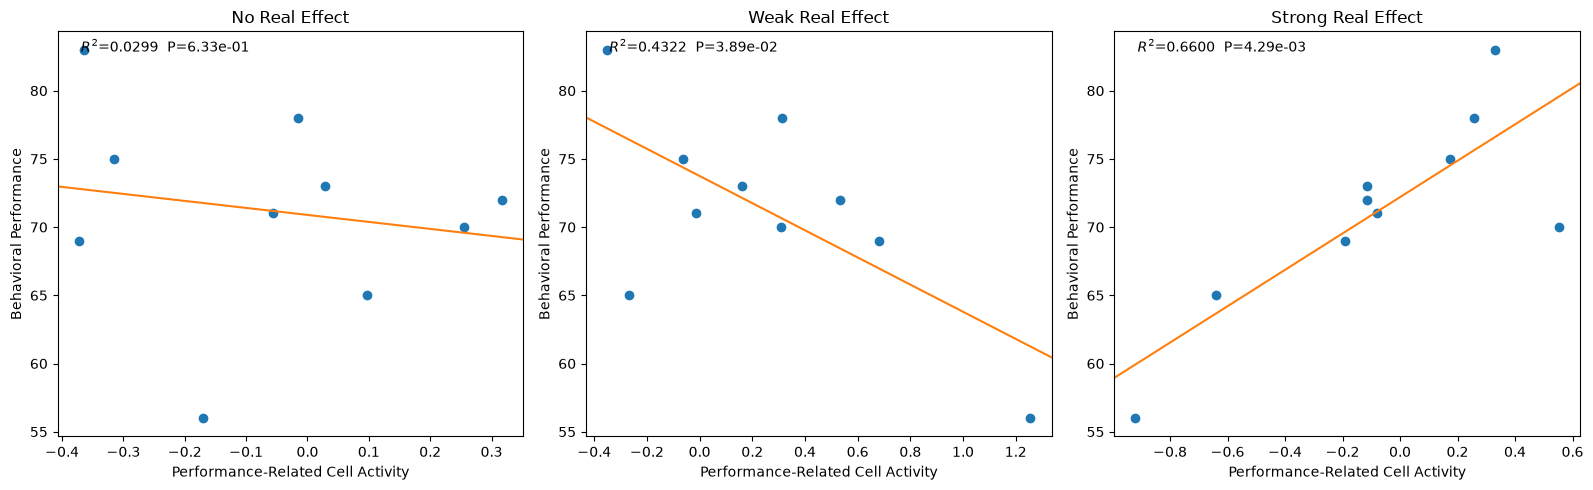

In [10]:
# Plot the train/test split results — no effect, weak effect, strong effect
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

panels = [
    (PRCA_test_null, Perf_test_null, "No Real Effect"),
    (split_real[0], split_real[1], "Weak Real Effect"),
    (split_real_strong[0], split_real_strong[1], "Strong Real Effect"),
]

for ax, (PRCA_panel, perf, label) in zip(axes, panels):
    annotate_corr(ax, PRCA_panel, perf, label)

plt.tight_layout()
plt.show()
